# 01 — Datos y diseño point-in-time

Reconstrucción del universo mensual, calendario de publicación y
auditoría de disponibilidad. El objetivo es comprobar que ninguna
variable use información publicada después de la fecha de emisión.

In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: C:\Users\litoa\OneDrive\Documents\GitHub\ml_finance_carenas\Morosidad_bancaria_arenas


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

base = pd.read_csv(
    ROOT / "data" / "processed" / "modeling_base.csv",
    parse_dates=["observation_date", "forecast_issue_date", "target_date_h6", "target_available_date_h6"],
)
features = pd.read_csv(
    ROOT / "data" / "processed" / "model_matrix_consumption_h6_v001.csv",
    parse_dates=["observation_date", "forecast_issue_date"],
)

summary = pd.Series({
    "observaciones mensuales": len(base),
    "inicio": base["observation_date"].min().date(),
    "fin": base["observation_date"].max().date(),
    "filas de desarrollo": int((base["split"] == "development").sum()),
    "filas de holdout": int((base["split"] == "holdout").sum()),
    "filas con features completas": int(features["complete_features"].sum()),
}, name="valor")
summary.to_frame()

,valor
observaciones mensuales,148
inicio,2014-03-01
fin,2026-06-01
filas de desarrollo,118
filas de holdout,24
filas con features completas,136


## Auditoría de disponibilidad

In [3]:
issue_date = pd.to_datetime(base["forecast_issue_date"])
available_columns = [column for column in base.columns if column.endswith("__available_date")]
violations = {}
for column in available_columns:
    available = pd.to_datetime(base[column], errors="coerce")
    violations[column] = int(((available > issue_date) & available.notna()).sum())

audit = pd.Series(violations, name="violaciones").to_frame()
assert audit["violaciones"].sum() == 0, "Se detectó look-ahead por disponibilidad"
audit

,violaciones
imacec_sa__available_date,0
ipc_yoy__available_date,0
unemployment_rate__available_date,0
tpm_monthly_average__available_date,0
usdclp_monthly_average__available_date,0
consumer_lending_rate__available_date,0
real_consumer_loans__available_date,0
real_m1_average__available_date,0


## Evolución de la morosidad observada

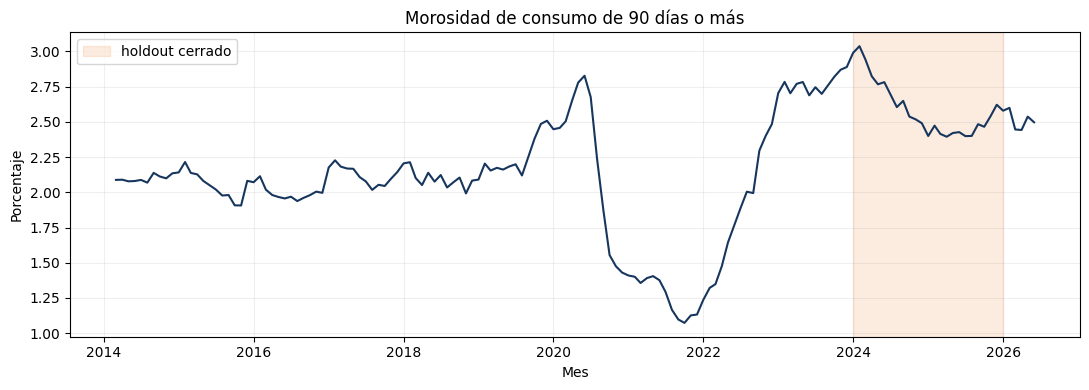

In [4]:
figure, axis = plt.subplots(figsize=(11, 4))
axis.plot(base["observation_date"], base["npl90_consumption_percent_t"], color="#17365d")
axis.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-12-31"), color="#f4b183", alpha=0.25, label="holdout cerrado")
axis.set(title="Morosidad de consumo de 90 días o más", ylabel="Porcentaje", xlabel="Mes")
axis.legend()
axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Lectura:** la base contiene 148 meses continuos y la auditoría no
encuentra variables publicadas después de la fecha de emisión. El
área sombreada corresponde al holdout reservado, no utilizado para
seleccionar ni evaluar modelos.